In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("Watera.csv")

In [3]:
import sys
!{sys.executable} -m pip install feature-engine

In [4]:
from feature_engine.outliers import Winsorizer 

### Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler
scalar= StandardScaler()   # initializing 
df[['tds']]=scalar.fit_transform(df[['tds']])

In [7]:
df.head(2)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,1.154470,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,0.234397,3.93,313.10,153.36,9.92,20.69,2.07,0


In [8]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
df[["conductivity"]]=scalar.fit_transform(df[['conductivity']])

In [9]:
from sklearn.preprocessing import RobustScaler
scalar=RobustScaler()
df[["hardness"]]=scalar.fit_transform(df[['hardness']])

In [10]:
df.head(2)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,0.707799,1.154470,2.12,208.39,0.008780,7.22,17.32,2.23,0
1,6.41,-0.117730,0.234397,3.93,313.10,0.003837,9.92,20.69,2.07,0


In [20]:
df=pd.read_csv("social_media.csv")
df.head(2)

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [22]:
# null 
df.isnull().sum()

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

In [25]:
# handle null values
df['daily_social_media_time']=df['daily_social_media_time'].fillna(df['daily_social_media_time'].mean())

In [26]:
df.isnull().sum()

age                                  0
gender                               0
job_type                             0
daily_social_media_time              0
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

<Axes: xlabel='weekly_offline_hours'>

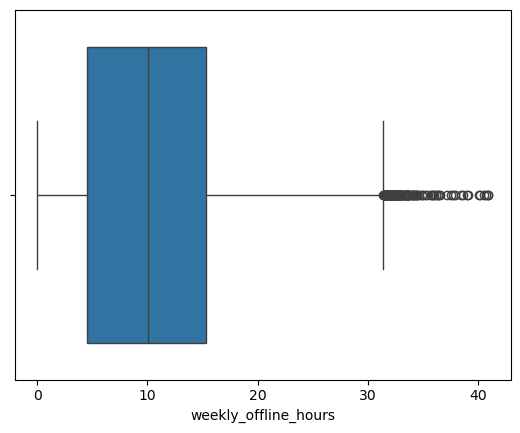

In [28]:
sns.boxplot(data=df,x='weekly_offline_hours')

In [29]:
Q1=df['weekly_offline_hours'].quantile(0.25)

In [30]:
Q3=df['weekly_offline_hours'].quantile(0.75)

In [31]:
IQR=Q3-Q1

In [33]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print(lower)
print(upper)

-11.596534531854738
31.439215468564196


In [34]:
#feature SCaling
df.duplicated().sum()

np.int64(0)

In [35]:
# feature scaling 
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[['weekly_offline_hours']]=sc.fit_transform(df[['weekly_offline_hours']])

In [36]:
df.head(2)

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,1.588729,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,-1.423109,3.412427
